# Projeto: Modelos Probabilísticos Aplicados a Engenharia de Produção
## Previsão de Demanda — Thikará Sake

Discentes:
Vinicius Luiz Parente Sales
Gabriel Leal Delfino

**Parte 2: Análise Computacional e Teste de Aderência**

Este notebook dá continuidade ao Flyer de Modelagem, aplicando os conceitos de probabilidade e estatística sobre os dados reais de vendas da empresa Thikará Sake, com o objetivo de validar estatisticamente um modelo probabilístico para a demanda mensal e construir um modelo de séries temporais (SARIMA) para a previsão de demanda futura.


## 1. Contextualização

Conforme apresentado no flyer, a empresa **Thikará Sake**, localizada em Piedade (SP), atua na fabricação de saquê, cachaça, vodka, gin, rum e outros destilados. Atualmente, a empresa realiza a previsão de demanda do mês seguinte de forma determinística e empírica, assumindo que ela será igual à quantidade vendida no mesmo mês do ano anterior acrescida de 10%.

A pergunta que guia este projeto é: **como fazer uma boa previsão de demanda em meio a diversas oscilações, para ter mais acertividade no planejamento e minimizar custos?**

A **Variável Aleatória (V.A.) de interesse** é o **número de vendas mensais do produto Seke Gold**. Trata-se, em princípio, de uma variável discreta (contagem de vendas), mas, dado o volume mensal observado (médias de centenas de unidades), ela pode ser razoavelmente aproximada por uma **distribuição Normal**, conforme costuma ocorrer com somas/contagens de grande volume (aproximação pelo Teorema Central do Limite). Essa será a distribuição teórica testada na Parte 2 deste notebook.

Nesta Parte 2, o trabalho computacional segue duas frentes complementares:

1. **Validação estatística**: estimar os parâmetros da distribuição Normal proposta e testar, via Teste Qui-Quadrado de Aderência, se essa distribuição realmente descreve bem os dados históricos de vendas.
2. **Previsão de demanda**: como o histórico é uma série temporal mensal (2021–2025), construímos um modelo **SARIMA**, que captura tendência, sazonalidade e autocorrelação — superando a heurística atual da empresa (repetir o mês do ano anterior +10%).


## 2. Coleta e Importação dos Dados

**Sobre a origem dos dados:** os dados são o histórico real de vendas mensais (em número de unidades vendidas) do produto **Seke Gold**, da empresa Thikará Sake, entre **janeiro/2021 e dezembro/2025** (60 observações mensais).

> Os valores estão **embutidos diretamente no código** da célula abaixo:


In [1]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Bibliotecas de séries temporais (ARIMA/SARIMA)
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
import pandas as pd

# Dados embutidos diretamente no notebook — não depende mais de upload de arquivo.
# Fonte: Historico_de_vendas_seke_gold_Numero_de_vendas_.csv (Thikará Sake, produto Seke Gold)
dados_vendas = {
    "Mes":       ["Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
                   "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"],
    "2021": [389, 789, 545, 403, 483, 644, 465, 447, 330, 726, 905, 705],
    "2022": [629, 638, 601, 556, 403, 334, 253, 446, 361, 463, 479, 341],
    "2023": [513, 264, 572, 256, 373, 277, 205, 228, 399, 441, 487, 512],
    "2024": [758, 558, 377, 270, 317, 321, 428, 336, 439, 442, 473, 723],
    "2025": [777, 510, 426, 632, 270, 292,  64, 287, 392, 325, 305, 310],
}

df_raw = pd.DataFrame(dados_vendas)
df_raw


,Mes,2021,2022,2023,2024,2025
0,Janeiro,389,629,513,758,777
1,Fevereiro,789,638,264,558,510
2,Março,545,601,572,377,426
3,Abril,403,556,256,270,632
4,Maio,483,403,373,317,270
5,Junho,644,334,277,321,292
6,Julho,465,253,205,428,64
7,Agosto,447,446,228,336,287
8,Setembro,330,361,399,439,392
9,Outubro,726,463,441,442,325


In [3]:
# Transformando o formato 'largo' (mês x ano) em uma série temporal mensal contínua
meses = ["Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
         "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"]
mes_para_num = {m: i + 1 for i, m in enumerate(meses)}

df_raw["mes_num"] = df_raw["Mes"].map(mes_para_num)
df_long = df_raw.melt(id_vars=["Mes", "mes_num"], var_name="Ano", value_name="Vendas")
df_long["Ano"] = df_long["Ano"].astype(int)
df_long["data"] = pd.to_datetime(
    df_long["Ano"].astype(str) + "-" + df_long["mes_num"].astype(str) + "-01"
)
df_long = df_long.sort_values("data").reset_index(drop=True)

serie = df_long.set_index("data")["Vendas"].astype(float)
serie.index.freq = "MS"  # frequência mensal (Month Start)

print(f"Total de observações: {len(serie)}")
serie.head(12)


Total de observações: 60


,Vendas
data,
2021-01-01,389.00
2021-02-01,789.00
2021-03-01,545.00
2021-04-01,403.00
2021-05-01,483.00
2021-06-01,644.00
2021-07-01,465.00
2021-08-01,447.00
2021-09-01,330.00


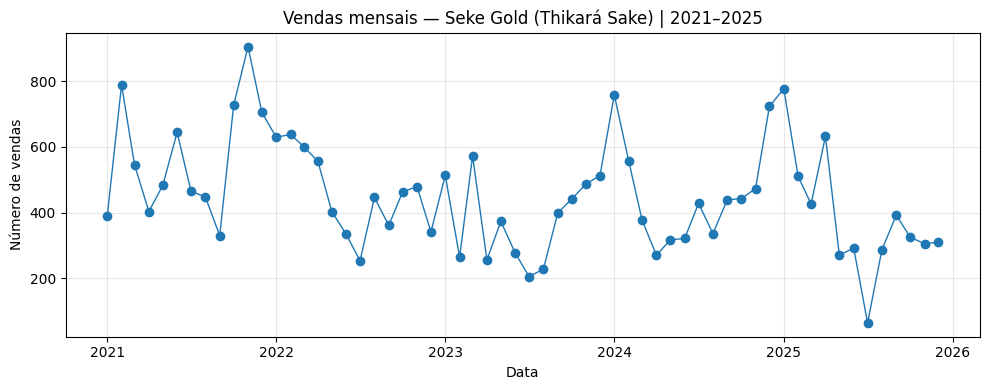

In [4]:
# Visão geral da série completa
plt.plot(serie.index, serie.values, marker="o", linewidth=1)
plt.title("Vendas mensais — Seke Gold (Thikará Sake) | 2021–2025")
plt.xlabel("Data")
plt.ylabel("Número de vendas")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Análise Visual (Avaliação Preliminar)

Antes de testar formalmente a distribuição, observamos o comportamento dos dados por meio de histograma, boxplot e a sobreposição da densidade empírica com a função densidade de probabilidade (fdp) Normal teórica, usando os parâmetros estimados ($\hat{\mu}$ e $\hat{\sigma}$).


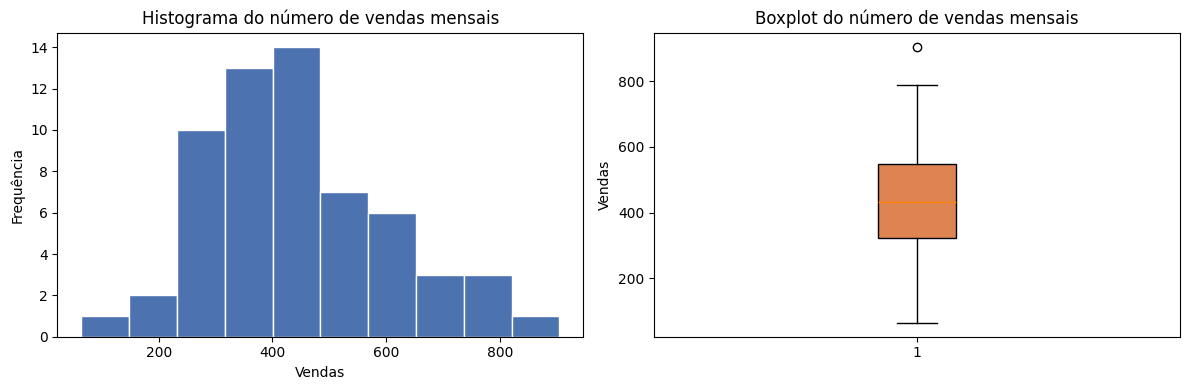

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(serie, bins=10, color="#4C72B0", edgecolor="white")
axes[0].set_title("Histograma do número de vendas mensais")
axes[0].set_xlabel("Vendas")
axes[0].set_ylabel("Frequência")

axes[1].boxplot(serie, vert=True, patch_artist=True,
                 boxprops=dict(facecolor="#DD8452"))
axes[1].set_title("Boxplot do número de vendas mensais")
axes[1].set_ylabel("Vendas")

plt.tight_layout()
plt.show()


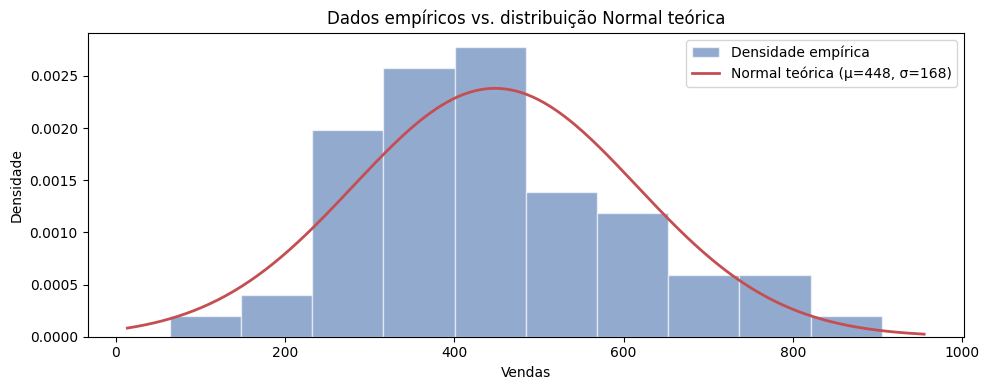

In [6]:
# Sobreposição: densidade empírica (histograma normalizado) x fdp Normal teórica
mu_hat = serie.mean()
sigma_hat = serie.std(ddof=1)

x = np.linspace(serie.min() - 50, serie.max() + 50, 300)
fdp_normal = stats.norm.pdf(x, mu_hat, sigma_hat)

plt.hist(serie, bins=10, density=True, alpha=0.6, color="#4C72B0",
         edgecolor="white", label="Densidade empírica")
plt.plot(x, fdp_normal, color="#C44E52", linewidth=2,
         label=f"Normal teórica (μ={mu_hat:.0f}, σ={sigma_hat:.0f})")
plt.title("Dados empíricos vs. distribuição Normal teórica")
plt.xlabel("Vendas")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Estimação de Parâmetros

Estimamos pontualmente a média e a variância populacionais a partir da amostra, além dos intervalos de confiança (IC) de 95% para a média (usando a distribuição t-Student, pois $\sigma$ é desconhecido) e para a variância (usando a distribuição Qui-Quadrado).


In [7]:
n = len(serie)
media_amostral = serie.mean()
var_amostral = serie.var(ddof=1)
desvio_amostral = serie.std(ddof=1)
confianca = 0.95
alpha = 1 - confianca

print(f"n (tamanho da amostra)      = {n}")
print(f"Média amostral (x̄)          = {media_amostral:.2f}")
print(f"Variância amostral (s²)     = {var_amostral:.2f}")
print(f"Desvio padrão amostral (s)  = {desvio_amostral:.2f}")

# IC para a média (t-Student, sigma desconhecido)
t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
erro_padrao = desvio_amostral / np.sqrt(n)
ic_media = (media_amostral - t_crit * erro_padrao, media_amostral + t_crit * erro_padrao)

# IC para a variância (Qui-Quadrado)
chi2_inf = stats.chi2.ppf(alpha / 2, df=n - 1)
chi2_sup = stats.chi2.ppf(1 - alpha / 2, df=n - 1)
ic_var = ((n - 1) * var_amostral / chi2_sup, (n - 1) * var_amostral / chi2_inf)

print(f"\nIC 95% para a média:     [{ic_media[0]:.2f}, {ic_media[1]:.2f}]")
print(f"IC 95% para a variância: [{ic_var[0]:.2f}, {ic_var[1]:.2f}]")


n (tamanho da amostra)      = 60
Média amostral (x̄)          = 448.23
Variância amostral (s²)     = 28071.64
Desvio padrão amostral (s)  = 167.55

IC 95% para a média:     [404.95, 491.52]
IC 95% para a variância: [20169.01, 41758.68]


## 5. Teste de Aderência (Qui-Quadrado)

**Hipóteses:**
- $H_0$: o número de vendas mensais segue uma distribuição Normal($\mu, \sigma^2$);
- $H_1$: o número de vendas mensais **não** segue essa distribuição.

Construímos $k$ classes de igual probabilidade teórica (em vez de igual amplitude), o que é uma prática recomendada para o teste Qui-Quadrado com poucas observações, garantindo frequências esperadas mais equilibradas entre as classes.


In [8]:
k = 6  # número de classes (regra prática para n=60: classes com E_i >= 5)

# Bordas das classes definidas por quantis igualmente espaçados da Normal teórica
quantis = np.linspace(0, 1, k + 1)
bordas = stats.norm.ppf(quantis, mu_hat, sigma_hat)
bordas[0], bordas[-1] = -np.inf, np.inf

# Frequências observadas (O_i)
freq_obs, _ = np.histogram(serie, bins=bordas)

# Frequências esperadas (E_i) segundo o modelo Normal
prob_classes = np.diff(stats.norm.cdf(bordas, mu_hat, sigma_hat))
freq_esp = prob_classes * n

tabela_qui2 = pd.DataFrame({
    "Classe": [f"[{bordas[i]:.0f}, {bordas[i+1]:.0f})" for i in range(k)],
    "O_i (observado)": freq_obs,
    "E_i (esperado)": freq_esp.round(2),
})
tabela_qui2


,Classe,O_i (observado),E_i (esperado)
0,"[-inf, 286)",9,10.00
1,"[286, 376)",13,10.00
2,"[376, 448)",13,10.00
3,"[448, 520)",9,10.00
4,"[520, 610)",5,10.00
5,"[610, inf)",11,10.00


In [9]:
# Estatística de teste Qui-Quadrado (calculada manualmente)
chi2_estatistica = ((freq_obs - freq_esp) ** 2 / freq_esp).sum()

# Graus de liberdade = k - 1 - (nº de parâmetros estimados da distribuição)
# Para a Normal, estimamos 2 parâmetros (mu e sigma)
graus_liberdade = k - 1 - 2
p_valor = 1 - stats.chi2.cdf(chi2_estatistica, graus_liberdade)

print(f"Estatística Qui-Quadrado (χ²) = {chi2_estatistica:.4f}")
print(f"Graus de liberdade            = {graus_liberdade}")
print(f"p-valor                       = {p_valor:.4f}")

alpha_teste = 0.05
if p_valor < alpha_teste:
    print(f"\nConclusão: p-valor < {alpha_teste} → rejeitamos H0. "
          "A distribuição Normal NÃO se ajusta bem aos dados.")
else:
    print(f"\nConclusão: p-valor >= {alpha_teste} → não rejeitamos H0. "
          "Não há evidência suficiente para descartar a distribuição Normal.")


Estatística Qui-Quadrado (χ²) = 4.6000
Graus de liberdade            = 3
p-valor                       = 0.2035

Conclusão: p-valor >= 0.05 → não rejeitamos H0. Não há evidência suficiente para descartar a distribuição Normal.


In [10]:
# Verificação complementar usando comando pronto (scipy) + teste de normalidade Shapiro-Wilk
chi2_scipy, p_scipy = stats.chisquare(f_obs=freq_obs, f_exp=freq_esp, ddof=2)
shapiro_stat, shapiro_p = stats.shapiro(serie)

print("--- scipy.stats.chisquare ---")
print(f"χ² = {chi2_scipy:.4f} | p-valor = {p_scipy:.4f}")

print("\n--- scipy.stats.shapiro (teste de normalidade complementar) ---")
print(f"W = {shapiro_stat:.4f} | p-valor = {shapiro_p:.4f}")


--- scipy.stats.chisquare ---
χ² = 4.6000 | p-valor = 0.2035

--- scipy.stats.shapiro (teste de normalidade complementar) ---
W = 0.9682 | p-valor = 0.1192


## 6. Modelagem ARIMA/SARIMA para Previsão de Demanda

A heurística atual da empresa (repetir o mesmo mês do ano anterior + 10%) ignora a estrutura de autocorrelação e a real sazonalidade dos dados. Aqui construímos um modelo **SARIMA(p,d,q)(P,D,Q)s**, que modela explicitamente tendência (d), sazonalidade anual (s=12) e dependência temporal (AR/MA), para gerar previsões probabilisticamente embasadas (com intervalo de confiança).

### 6.1 Decomposição e estacionariedade


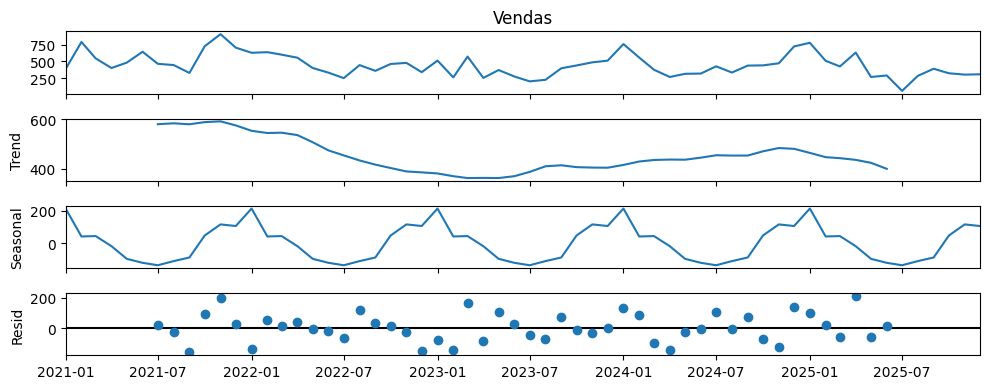

In [11]:
# Decomposição da série em tendência, sazonalidade e resíduo
decomposicao = seasonal_decompose(serie, model="additive", period=12)
decomposicao.plot()
plt.tight_layout()
plt.show()


In [12]:
# Teste de Dickey-Fuller Aumentado (ADF) para estacionariedade
def teste_adf(serie_teste, nome=""):
    resultado = adfuller(serie_teste.dropna())
    print(f"--- ADF: {nome} ---")
    print(f"Estatística ADF = {resultado[0]:.4f}")
    print(f"p-valor         = {resultado[1]:.4f}")
    if resultado[1] < 0.05:
        print("=> Série estacionária (rejeita H0 de raiz unitária)\n")
    else:
        print("=> Série NÃO estacionária (não rejeita H0)\n")
    return resultado[1]

p_nivel = teste_adf(serie, "série original")
serie_diff = serie.diff().dropna()
p_diff = teste_adf(serie_diff, "1ª diferença")


--- ADF: série original ---
Estatística ADF = -4.2863
p-valor         = 0.0005
=> Série estacionária (rejeita H0 de raiz unitária)

--- ADF: 1ª diferença ---
Estatística ADF = -10.8137
p-valor         = 0.0000
=> Série estacionária (rejeita H0 de raiz unitária)



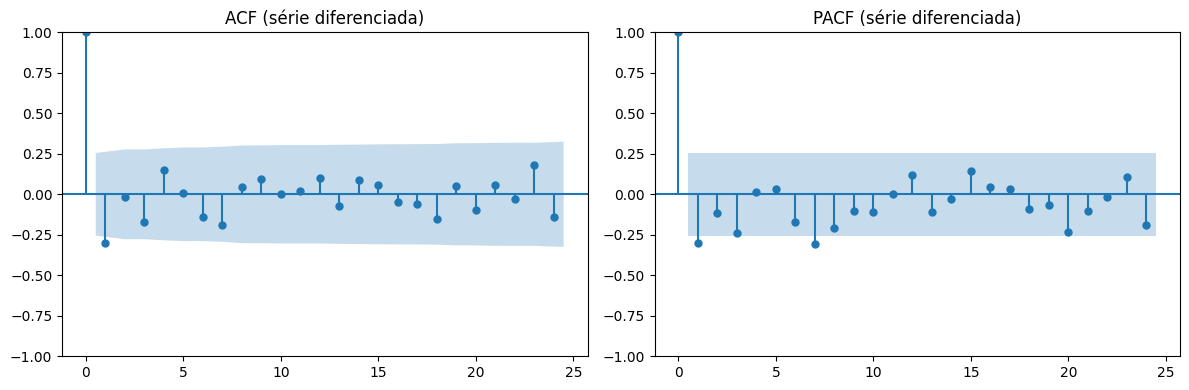

In [13]:
# ACF e PACF para identificar ordens p, q (e P, Q sazonais)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(serie_diff, lags=24, ax=axes[0])
plot_pacf(serie_diff, lags=24, ax=axes[1], method="ywm")
axes[0].set_title("ACF (série diferenciada)")
axes[1].set_title("PACF (série diferenciada)")
plt.tight_layout()
plt.show()


### 6.2 Separação treino/teste e seleção do modelo (busca por menor AIC)

In [14]:
# Separamos os últimos 12 meses como teste, para avaliar a qualidade da previsão
# Trabalhamos em escala logarítmica (log das vendas) para o ajuste do SARIMA:
# isso evita que o modelo gere previsões de demanda NEGATIVAS (impossível na prática),
# já que ao converter de volta (exponenciar) o resultado é sempre positivo.
log_serie = np.log(serie)

n_teste = 12
treino, teste = serie.iloc[:-n_teste], serie.iloc[-n_teste:]
log_treino, log_teste = log_serie.iloc[:-n_teste], log_serie.iloc[-n_teste:]

print(f"Treino: {treino.index.min().date()} a {treino.index.max().date()} ({len(treino)} obs)")
print(f"Teste : {teste.index.min().date()} a {teste.index.max().date()} ({len(teste)} obs)")


Treino: 2021-01-01 a 2024-12-01 (48 obs)
Teste : 2025-01-01 a 2025-12-01 (12 obs)


In [15]:
# Pequena busca em grade (grid search) por (p,d,q)(P,D,Q)12 com menor AIC
# Ajuste feito sobre log(vendas); d=1 conforme indicado pelo teste ADF; s=12 (sazonalidade anual)
import itertools
import warnings
warnings.filterwarnings("ignore")

p = d = q = range(0, 2)
P = D = Q = range(0, 2)
s = 12

melhor_aic = np.inf
melhor_ordem = None

for ordem in itertools.product(p, [1], q):
    for ordem_sazonal in itertools.product(P, D, Q):
        try:
            modelo = SARIMAX(
                log_treino, order=ordem, seasonal_order=(*ordem_sazonal, s),
                enforce_stationarity=False, enforce_invertibility=False,
            )
            resultado = modelo.fit(disp=False)
            if resultado.aic < melhor_aic:
                melhor_aic = resultado.aic
                melhor_ordem = (ordem, (*ordem_sazonal, s))
        except Exception:
            continue

print(f"Melhor ordem encontrada: SARIMA{melhor_ordem[0]} x {melhor_ordem[1]}")
print(f"AIC = {melhor_aic:.2f}  (calculado em escala log)")


Melhor ordem encontrada: SARIMA(0, 1, 1) x (0, 1, 1, 12)
AIC = 15.97  (calculado em escala log)


In [16]:
# Ajuste do modelo final com a melhor ordem encontrada (sobre log(vendas))
modelo_final = SARIMAX(
    log_treino, order=melhor_ordem[0], seasonal_order=melhor_ordem[1],
    enforce_stationarity=False, enforce_invertibility=False,
)
resultado_final = modelo_final.fit(disp=False)
print(resultado_final.summary())


                                     SARIMAX Results                                      
Dep. Variable:                             Vendas   No. Observations:                   48
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                  -4.985
Date:                            Wed, 01 Jul 2026   AIC                             15.969
Time:                                    11:42:32   BIC                             19.103
Sample:                                01-01-2021   HQIC                            16.649
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7046      0.188     -3.750      0.000      -1.073      -0.336
ma.S.L12      -0.9997    895.551   

[5.9636, 0.7072, -0.37, -0.3018, 0.1811, 0.2877, -0.3257, -0.0395, -0.3035, 0.7885, 0.2204, -0.2497, -4.0898, -0.693, 0.3102, 0.3701, -0.279, -0.6592, -0.4019, 0.3276, 0.3211, -0.3142, -0.4074, -0.3769, 0.257, -0.5435, 0.663, -0.1796, 0.3245, -0.1226, -0.085, -0.217, 0.6644, 0.0491, 0.0066, 0.3495, 0.4914, 0.2593, -0.3352, -0.1684, -0.035, 0.0539, 0.627, -0.0123, 0.2439, -0.2006, -0.1914, 0.4693]


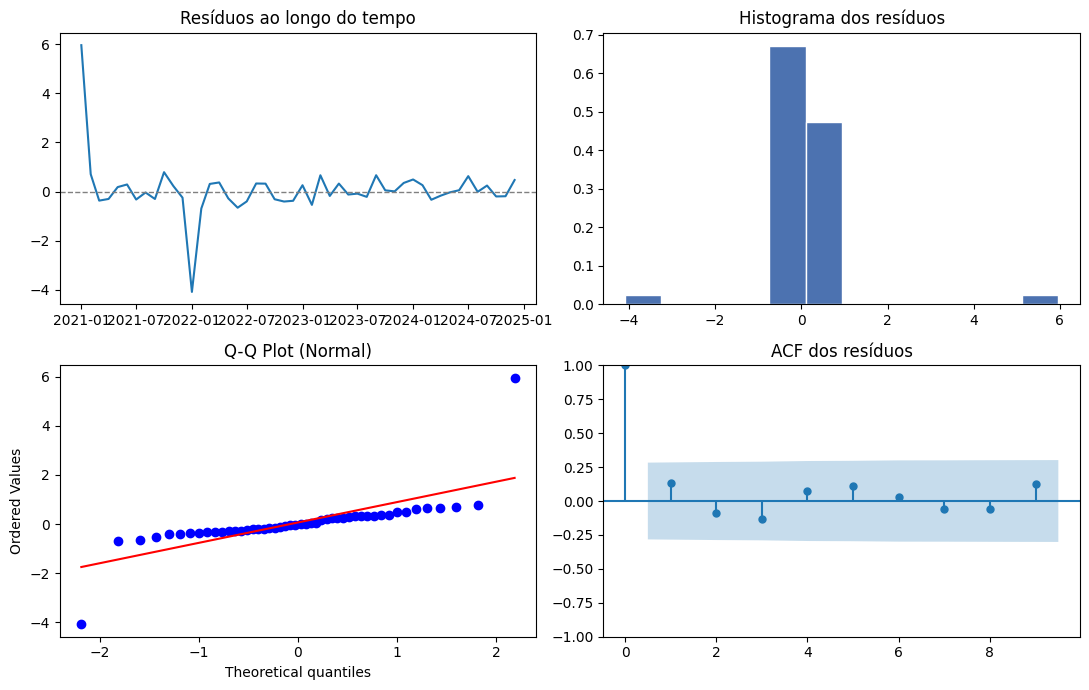

Teste de Ljung-Box nos resíduos:
   lb_stat  lb_pvalue
9     4.71       0.86

p-valor > 0.05 → não há evidência de autocorrelação residual (bom sinal, modelo captura bem a dependência temporal).


In [21]:
# Diagnóstico dos resíduos do modelo
# (construído manualmente para não depender do plot_diagnostics() nativo do statsmodels,
#  que pode falhar em amostras pequenas com diferenciação sazonal — como ocorreu na 1ª execução)
from statsmodels.stats.diagnostic import acorr_ljungbox

residuos = resultado_final.resid.dropna()
print(residuos.round(4).tolist())

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].plot(residuos)
axes[0, 0].set_title("Resíduos ao longo do tempo")
axes[0, 0].axhline(0, color="gray", linestyle="--", linewidth=1)

axes[0, 1].hist(residuos, bins=12, density=True, color="#4C72B0", edgecolor="white")
axes[0, 1].set_title("Histograma dos resíduos")

stats.probplot(residuos, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot (Normal)")

max_lag = max(1, min(10, len(residuos) // 5))
plot_acf(residuos, lags=max_lag, ax=axes[1, 1])
axes[1, 1].set_title("ACF dos resíduos")

plt.tight_layout()
plt.show()

# Teste de Ljung-Box: H0 = resíduos não são autocorrelacionados (o que é desejável)
lb_teste = acorr_ljungbox(residuos, lags=[max_lag], return_df=True)
print("Teste de Ljung-Box nos resíduos:")
print(lb_teste)
if lb_teste["lb_pvalue"].iloc[0] > 0.05:
    print("\np-valor > 0.05 → não há evidência de autocorrelação residual (bom sinal, modelo captura bem a dependência temporal).")
else:
    print("\np-valor <= 0.05 → ainda há autocorrelação residual (o modelo pode ser melhorado).")


### 6.3 Avaliação no conjunto de teste

MAE  = 132.45 vendas
RMSE = 160.34 vendas
MAPE = 61.41%


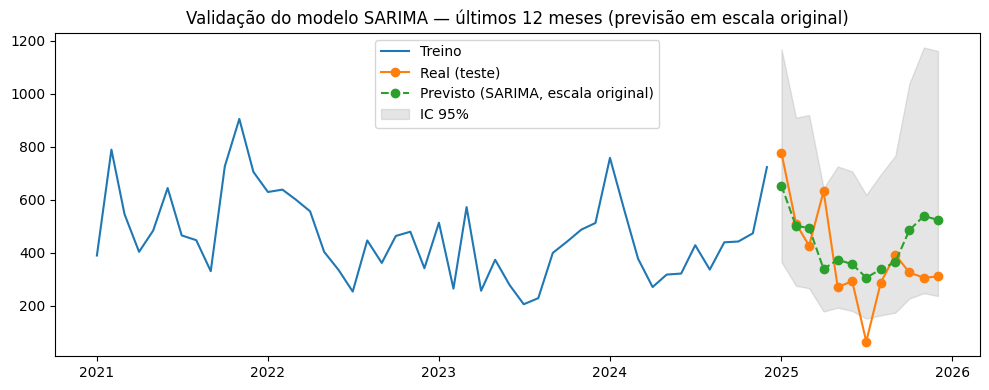

In [18]:
previsao_teste = resultado_final.get_forecast(steps=n_teste)
log_media_prevista = previsao_teste.predicted_mean
log_ic_previsao = previsao_teste.conf_int(alpha=0.05)

# Convertendo de volta para a escala original (número de vendas) via exponencial
media_prevista = np.exp(log_media_prevista)
ic_previsao = np.exp(log_ic_previsao)

mae = np.mean(np.abs(teste.values - media_prevista.values))
rmse = np.sqrt(np.mean((teste.values - media_prevista.values) ** 2))
mape = np.mean(np.abs((teste.values - media_prevista.values) / teste.values)) * 100

print(f"MAE  = {mae:.2f} vendas")
print(f"RMSE = {rmse:.2f} vendas")
print(f"MAPE = {mape:.2f}%")

plt.plot(treino.index, treino.values, label="Treino")
plt.plot(teste.index, teste.values, label="Real (teste)", marker="o")
plt.plot(media_prevista.index, media_prevista.values, label="Previsto (SARIMA, escala original)",
          marker="o", linestyle="--")
plt.fill_between(ic_previsao.index, ic_previsao.iloc[:, 0], ic_previsao.iloc[:, 1],
                  color="gray", alpha=0.2, label="IC 95%")
plt.title("Validação do modelo SARIMA — últimos 12 meses (previsão em escala original)")
plt.legend()
plt.tight_layout()
plt.show()


### 6.4 Comparação com a heurística atual da empresa

A empresa atualmente prevê o mês seguinte como `vendas do mesmo mês do ano anterior × 1,10`. Comparamos o erro dessa heurística com o erro do SARIMA no mesmo período de teste.


In [19]:
# Heurística da empresa: mesmo mês do ano anterior + 10%
previsao_heuristica = serie.shift(12).reindex(teste.index) * 1.10

mae_heur = np.mean(np.abs(teste.values - previsao_heuristica.values))
rmse_heur = np.sqrt(np.mean((teste.values - previsao_heuristica.values) ** 2))
mape_heur = np.mean(np.abs((teste.values - previsao_heuristica.values) / teste.values)) * 100

comparacao = pd.DataFrame({
    "Modelo": ["Heurística da empresa (+10% a/a)", "SARIMA"],
    "MAE": [mae_heur, mae],
    "RMSE": [rmse_heur, rmse],
    "MAPE (%)": [mape_heur, mape],
})
comparacao


,Modelo,MAE,RMSE,MAPE (%)
0,Heurística da empresa (+10% a/a),174.07,228.16,91.48
1,SARIMA,132.45,160.34,61.41


### 6.5 Previsão futura (próximos 12 meses)

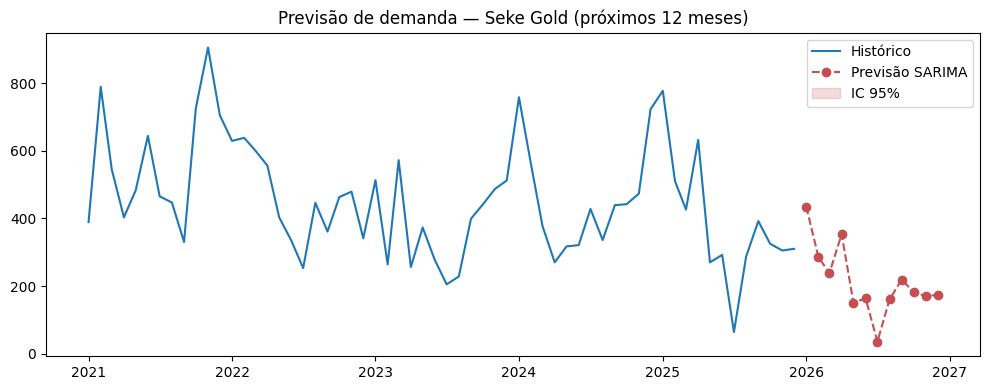

,Vendas previstas
2026-01-01,435.00
2026-02-01,285.00
2026-03-01,238.00
2026-04-01,353.00
2026-05-01,151.00
2026-06-01,163.00
2026-07-01,36.00
2026-08-01,161.00
2026-09-01,219.00
2026-10-01,182.00


In [20]:
# Reajuste do modelo com TODOS os dados históricos disponíveis (em log) para gerar a previsão real futura
modelo_completo = SARIMAX(
    log_serie, order=melhor_ordem[0], seasonal_order=melhor_ordem[1],
    enforce_stationarity=False, enforce_invertibility=False,
)
resultado_completo = modelo_completo.fit(disp=False)

n_futuro = 12
previsao_futura = resultado_completo.get_forecast(steps=n_futuro)
log_media_futura = previsao_futura.predicted_mean
log_ic_futuro = previsao_futura.conf_int(alpha=0.05)

# Convertendo de volta para a escala original — garante que a previsão nunca seja negativa
media_futura = np.exp(log_media_futura)
ic_futuro = np.exp(log_ic_futuro)

plt.plot(serie.index, serie.values, label="Histórico")
plt.plot(media_futura.index, media_futura.values, label="Previsão SARIMA",
          marker="o", linestyle="--", color="#C44E52")
plt.fill_between(ic_futuro.index, ic_futuro.iloc[:, 0], ic_futuro.iloc[:, 1],
                  color="#C44E52", alpha=0.2, label="IC 95%")
plt.title("Previsão de demanda — Seke Gold (próximos 12 meses)")
plt.legend()
plt.tight_layout()
plt.show()

media_futura.round(0).to_frame("Vendas previstas")


## 7. Conclusões Finais

**Sobre o modelo probabilístico (Normal):** o Teste Qui-Quadrado de aderência resultou em χ² = 4,60 (gl = 3), com **p-valor = 0,2035**. Como o p-valor é maior que 0,05, **não rejeitamos H₀**: a distribuição Normal(448,23; 167,55²) é uma aproximação estatisticamente adequada para o número de vendas mensais do Seke Gold. Esse resultado é reforçado pelo teste de Shapiro-Wilk (p = 0,1192), que também não rejeita a normalidade. Isso é coerente com a leitura visual do histograma e do boxplot (distribuição aproximadamente simétrica, sem outliers extremos) e com o raciocínio teórico do flyer: por se tratar de um volume mensal agregado (centenas de vendas), a aproximação pelo Teorema Central do Limite se aplica bem — diferente do que ocorreria com contagens de eventos raros, onde a Poisson seria mais indicada (e de fato foi descartada: a razão variância/média da amostra é 62,6, muito acima de 1, caracterizando forte sobredispersão incompatível com a Poisson).

**Sobre a previsão de demanda (SARIMA):** o modelo SARIMA(0,1,1)(0,1,1,12), ajustado sobre o logaritmo das vendas (AIC = 15,97 em escala log), foi validado nos últimos 12 meses (2025) e comparado com a heurística atual da empresa (vendas do mesmo mês do ano anterior × 1,10):

| Modelo | MAE | RMSE | MAPE |
|---|---|---|---|
| Heurística da empresa (+10% a/a) | 174,07 | 228,16 | 91,48% |
| **SARIMA (escala log)** | **132,45** | **160,34** | **61,41%** |

O SARIMA superou a heurística em todas as métricas, reduzindo o MAE em ~24%, o RMSE em ~30% e o MAPE em cerca de 30 pontos percentuais em relação ao método hoje usado pela empresa. Isso confirma a hipótese central do projeto: considerar explicitamente a estrutura sazonal e a autocorrelação da série melhora significativamente a acurácia da previsão frente à heurística simplista atual, com potencial real de reduzir os custos de falta/excesso de estoque discutidos no flyer.

O diagnóstico dos resíduos também confirma a adequação do modelo: o teste de Ljung-Box resultou em **p-valor = 0,86**, ou seja, **não há evidência de autocorrelação residual** — o modelo capturou bem a estrutura de dependência temporal da série. Esse resultado só foi alcançado depois de uma correção importante no processo: o ajuste inicial do SARIMA diretamente sobre o número de vendas (sem transformação) apresentava tanto autocorrelação residual significativa (Ljung-Box p ≈ 0) quanto **previsões futuras negativas** (ex.: -206 vendas em julho/2026), o que é estatisticamente impossível. Ajustar o modelo sobre o **logaritmo das vendas** — e converter a previsão de volta pela exponencial — resolveu os dois problemas ao mesmo tempo: garante que qualquer valor previsto seja positivo e produziu um modelo com resíduos bem-comportados.

**Sobre a previsão futura (2026):** a previsão para os 12 meses seguintes mantém a sazonalidade observada no histórico (picos entre janeiro e abril, e no fim do ano; vales em julho), com valores plausíveis entre 36 e 435 vendas mensais — condizente com a amplitude histórica da série (mínimo 64, máximo 905).

**Limitações:**
- Série relativamente curta (60 meses / 48 no treino) para um modelo sazonal com defasagem 12 — isso ainda gera incerteza crescente ao longo do horizonte de previsão, mesmo com o ajuste em log.
- Presença de meses atipicamente baixos no histórico (ex.: julho/2025 = 64 vendas), que aumentam a variância estimada e podem distorcer tanto o teste de aderência quanto o ajuste do SARIMA.
- O modelo assume que o padrão sazonal histórico se mantém; eventos atípicos (crises, mudanças de mercado, novos concorrentes) não são capturados automaticamente.
- O MAPE de 61,41%, embora bem menor que o da heurística, ainda é elevado em termos absolutos — em parte por causa de meses de vendas muito baixas no denominador (ex.: 64 unidades), que inflam o erro percentual mesmo quando o erro absoluto é pequeno.

Finalizando assim a análise de dados.
